We want to evaluate the model output using metrics from object detection to better understand the model performance

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import json

In [2]:
def compute_iou(xmin, ymin, xmax, ymax, xmin2, ymin2, xmax2, ymax2):
    if xmin2 > xmax2 or ymin2 > ymax2:
        return 0
    A1 = (xmax - xmin) * (ymax - ymin)
    A2 = (xmax2 - xmin2) * (ymax2 - ymin2)
    Ai = (min(xmax,xmax2) - max(xmin,xmin2)) * (min(ymax,ymax2) - max(ymin,ymin2))
    if Ai / (A1 + A2 - Ai) < 0:
        print((xmin, ymin, xmax, ymax, xmin2, ymin2, xmax2, ymax2))
    return max(0, Ai / (A1 + A2 - Ai))

In [3]:
!ls ../output/

output_noobj  output_noobj_altlabel  output_obj  output_obj_altlabel


In [59]:
with open("../output/output_noobj/output.csv", "r") as f:
    noobj_result_csv = f.readlines()

In [60]:
noobj_iou = []
for line in noobj_result_csv:
    name, label_xmin, label_ymin, label_xmax, label_ymax, xmin, ymin, xmax, ymax = line.split(",")
    ymax = ymax.strip()
    #convert coordinates to int
    label_xmin, label_ymin, label_xmax, label_ymax, xmin, ymin, xmax, ymax = [int(x) for x in [label_xmin, label_ymin, label_xmax, label_ymax, xmin, ymin, xmax, ymax]]

    noobj_iou.append(compute_iou(label_xmin, label_ymin, label_xmax, label_ymax, xmin, ymin, xmax, ymax))

(124, 113, 187, 356, 71, 20, 278, 85)
(142, 83, 218, 207, 224, 88, 391, 305)
(244, 152, 425, 258, 121, 149, 221, 300)
(1, 171, 73, 275, 130, 24, 443, 318)


In [36]:
len(obj_iou)

277

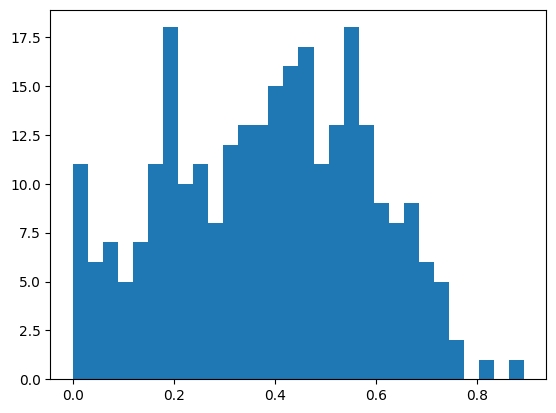

In [61]:
plt.hist(noobj_iou, bins=30)
plt.show()

In [65]:
with open("../output/output_noobj_altlabel/output.csv", "r") as f:
    noobj_altlabel_result_csv = f.readlines()

In [15]:
def get_corners(x_origin, y_origin, width, height):
    xmin = x_origin - (width/2)
    xmax = x_origin + (width/2)
    ymin = y_origin - (height/2)
    ymax = y_origin + (height/2)
    return xmin, ymin, xmax, ymax

In [66]:
noobj_altlabel_iou = []
for line in noobj_altlabel_result_csv:
    name, label_xmin, label_ymin, label_xmax, label_ymax, xmin, ymin, xmax, ymax = line.split(",")
    ymax = ymax.strip()
    #convert coordinates to int
    label_xmin, label_ymin, label_xmax, label_ymax, xmin, ymin, xmax, ymax = [int(x) for x in [label_xmin, label_ymin, label_xmax, label_ymax, xmin, ymin, xmax, ymax]]
    label_xmin, label_ymin, label_xmax, label_ymax = get_corners(label_xmin, label_ymin, label_xmax, label_ymax)
    xmin, ymin, xmax, ymax = get_corners(xmin, ymin, xmax, ymax)
    noobj_altlabel_iou.append(compute_iou(label_xmin, label_ymin, label_xmax, label_ymax, xmin, ymin, xmax, ymax))

(390.0, 142.5, 522.0, 229.5, 260.0, 96.0, 322.0, 222.0)
(341.0, 193.0, 363.0, 249.0, 191.0, 159.5, 251.0, 238.5)
(100.5, 30.5, 151.5, 185.5, 177.5, 166.5, 234.5, 243.5)
(219.5, 134.0, 264.5, 186.0, 191.5, 251.0, 258.5, 323.0)
(340.5, 157.0, 439.5, 377.0, 232.0, 186.0, 288.0, 254.0)
(187.0, 8.5, 235.0, 79.5, 156.0, 278.0, 234.0, 320.0)
(334.0, 18.5, 394.0, 197.5, 241.0, 88.0, 313.0, 260.0)
(335.5, 235.0, 354.5, 263.0, 181.5, 207.5, 238.5, 276.5)
(288.0, 196.5, 350.0, 491.5, 183.5, 212.0, 232.5, 284.0)


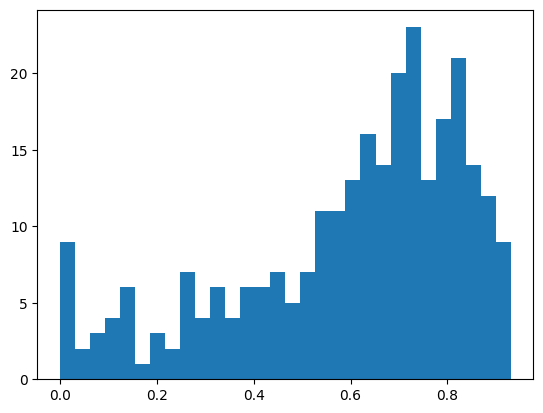

In [67]:
plt.hist(noobj_altlabel_iou, bins=30)
plt.show()

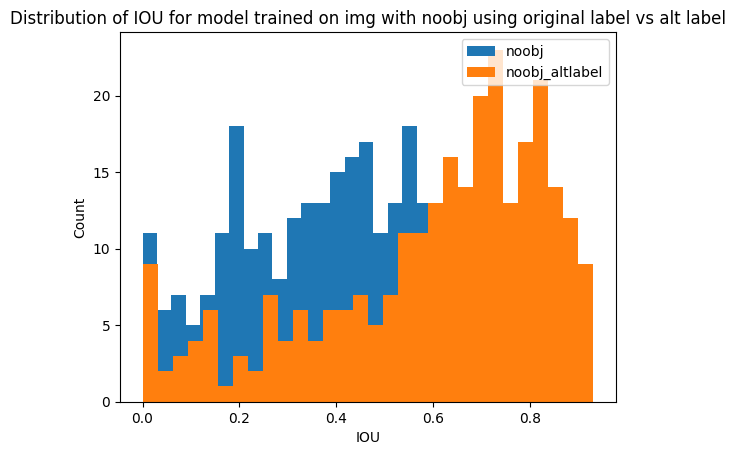

In [74]:
plt.hist(noobj_iou, bins=30, label="noobj")
plt.hist(noobj_altlabel_iou, bins=30, label="noobj_altlabel")
plt.legend(loc='upper right')
plt.title("Distribution of IOU for model trained on img with noobj using original label vs alt label")
plt.ylabel("Count")
plt.xlabel("IOU")
plt.savefig("name.png")
plt.show()

In [76]:
example_count = len(obj_iou)
noobj_label_correct = []
noobj_altlabel_correct = []
for threshold in [0.5, 0.75, 0.8, 0.9]:
    noobj_label_correct.append(len([x for x in noobj_iou if x >= threshold]))
    noobj_altlabel_correct.append(len([x for x in noobj_altlabel_iou if x >= threshold]))

In [56]:
#thresholds = np.array([0.5, 0.75, 0.8, 0.9])
thresholds = [str(x) for x in [0.5, 0.75, 0.8, 0.9]]

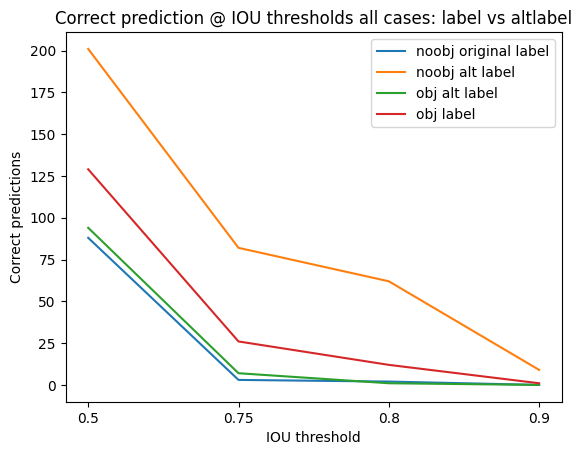

In [79]:
plt.plot(thresholds, noobj_label_correct,label="noobj original label")
plt.ylabel("Correct predictions")
plt.xlabel("IOU threshold")
plt.plot(thresholds, noobj_altlabel_correct, label="noobj alt label")
plt.plot(thresholds, obj_altlabel_correct, label="obj alt label")
plt.plot(thresholds, obj_label_correct, label="obj label")
plt.legend(loc="upper right")
plt.title("Correct prediction @ IOU thresholds all cases: label vs altlabel")

plt.savefig("name.png")
plt.show()

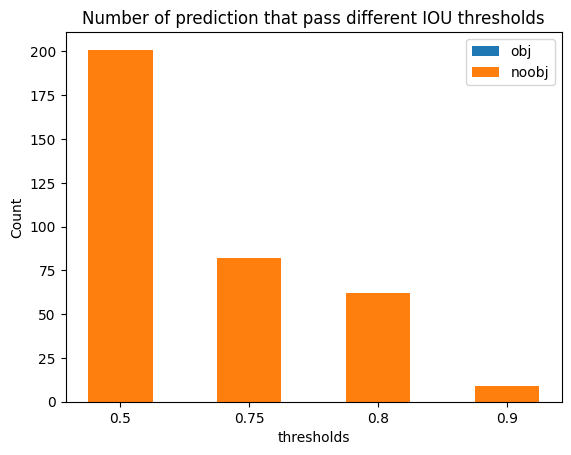

In [23]:
plt.bar(thresholds, obj_correct, width=0.5, label="obj")
plt.bar(thresholds, noobj_correct, width=0.5, label="noobj")
plt.title("Number of prediction that pass different IOU thresholds")
plt.ylabel("Count")
plt.legend(loc='upper right')
plt.xlabel("thresholds")
plt.show()